In [1]:
import os
import sys
from pathlib import Path
import importlib.util
import jax
import jax.numpy as jnp

import numpy as np

import matplotlib.pyplot as plt
import matplotlib
from tqdm.auto import tqdm

import pta_flatland
from pta_flatland import plot_func as pf
from pta_flatland.model import covariance_matrix
from pta_flatland.det_stat import df_weights, np_weights, bayes_factor, mlp_apply
from pta_flatland.utils import triu_features, load_model

plt.style.use(pta_flatland.STYLE_PATH)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
Path("figures").mkdir(exist_ok=True)

colors = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
color_1 = '#006e90'
color_2 = '#f18f01'


/home/mauro/.pyenv/versions/test_pta/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_config(config_file):
    """Import a config.py from an arbitrary path, without touching sys.path."""
    path = Path(config_file).expanduser().resolve()
    spec = importlib.util.spec_from_file_location(path.stem, path)
    cfg = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(cfg)
    return cfg


def load_roc_npz(path):
    npz = np.load(path)
    res = {}
    for key in npz.files:
        method, label, field = key.split("__")
        res.setdefault(method, {}).setdefault(label, {})[field] = npz[key]
    return {m: {l: (d["fpr"], d["tpr"], float(d["auc"])) for l, d in bd.items()}
            for m, bd in res.items()}


def _rms(v):
    """Unit-RMS normalisation for direction comparison.

    RMS, not L2: ||v|| grows like sqrt(len(v)), so an L2-normalised
    weight vector's amplitude depends on M = n_pul*(n_pul+1)/2 and on
    the theory grid's point count. Dividing by the RMS removes that
    dependence, so panels with different n_pul (simple_weak has 100,
    the rest 50) and the analytic curve all land on one scale.
    """
    v = np.asarray(v, float)
    return v / np.sqrt(np.mean(v**2))


def net_output(params, D_batch, mu, sig_std):
    """Raw logit output of an mlp/mlp_linear model on a batch of D matrices --
    same standardisation as training (train.py), so the score is comparable
    to the one the network was actually optimised against."""
    X = triu_features(D_batch)
    X = (X - mu) / sig_std
    return np.asarray(mlp_apply(params, jnp.asarray(X)))


def exact_log_bf(D_batch, phi_j, Ns, priors, log_uniform, n_mc, seed=0):
    """Exact (MC-integrated) log Bayes factor for each D in D_batch."""
    key = jax.random.PRNGKey(seed)
    out = np.empty(len(D_batch))
    for i, D in enumerate(tqdm(D_batch)):
        key, sub = jax.random.split(key)
        out[i] = bayes_factor(
            phi_j, jnp.asarray(D), Ns, priors,
            log_uniform=log_uniform, key=sub, n_mc=n_mc,
        )["log_BF"]
    return out

## Money plot

In [3]:
_STRENGTHS = ["weak", "strong"]
_SIMPLE_KEYS = [f"simple_{s}" for s in _STRENGTHS]
# Use the standard composite runs; no Cl-based configuration is required.
_COMPOSITE_KEYS = [f"composite_{s}" for s in _STRENGTHS]
_ALL_KEYS = _SIMPLE_KEYS + _COMPOSITE_KEYS

# ── configs and ROC curves ───────────────────────────────────────────────────
cfgs = {k: load_config(f"./config_files/{k}.py") for k in _ALL_KEYS}
rocs = {k: load_roc_npz(f"./plots/{k}/roc.npz") for k in _ALL_KEYS}

# ── weight data for weak and strong scenarios ────────────────────────────────
# theta_1 is each scenario's OWN injected-signal point (sc), not
# sc["stat_params"] -- for composite_*, stat_params deliberately zeroes
# P2r/P2i (it's the theta_1 slot for the quad detection statistics, where
# map_statistic ignores theta_1 anyway), which would make theta_1==theta_0
# here and collapse W_np/W_df to zero. The weight comparison instead wants
# the analytical weight AT the scenario's actual test point -- same
# convention as story_plot.py's _weight_ref_point.
w_data = {}
for key in _ALL_KEYS:
    cfg = cfgs[key]
    sc  = cfg.test_scenarios[0]
    t1  = {k: float(sc[k]) for k in ("sigma2_noise", "sigma2_gwb", "P2r", "P2i")}
    t0  = dict(t1, P2r=0.0, P2i=0.0)

    ds    = np.load(os.path.join(f"./out/{key}", "datasets.npz"))
    phi   = ds["_phi_j"]
    jphis = jnp.array(phi)
    n     = len(phi)
    r, c  = np.triu_indices(n)
    sig_std = ds["_sig_std"]

    # NP weights: w_NP = C0^-1 - C1^-1 (np_weights takes the covariance
    # matrices themselves, not phi/theta -- same pattern det_stat's own
    # likelihood_ratio() uses). Triu vector with off-diag ×2 so
    # w·triu(D) = Tr(W_NP D).
    C0     = covariance_matrix(jphis, **t0)
    C1     = covariance_matrix(jphis, **t1)
    W_np   = np.array(np_weights(C0, C1))
    w_triu = np.where(r == c, W_np[r, c], 2.0 * W_np[r, c])
    w_np   = _rms(w_triu)

    W_df   = np.array(df_weights(jphis, t0, t1))
    w_triu = np.where(r == c, W_df[r, c], 2.0 * W_df[r, c])
    w_df   = _rms(w_triu)

    # MLP linear is trained on STANDARDISED triu(D) features, so its raw
    # weight must be divided by sig_std before comparison in raw units.
    params = load_model(os.path.join(f"./out/{key}", "mlp_linear.pkl"))
    w_std = np.asarray(params[0][0]).ravel()
    w_raw = w_std / sig_std
    w_mlp = _rms(w_raw)
    if w_mlp @ w_np < 0:
        w_mlp = -w_mlp

    phi_ab = (phi[r] + phi[c])
    w_data[key] = dict(phi_ab=phi_ab, w_np=w_np, w_mlp=w_mlp, w_df=w_df)

print("ROC data loaded for:", list(rocs.keys()))
print("Weight data loaded for:", list(w_data.keys()))

ROC data loaded for: ['simple_weak', 'simple_strong', 'composite_weak', 'composite_strong']
Weight data loaded for: ['simple_weak', 'simple_strong', 'composite_weak', 'composite_strong']


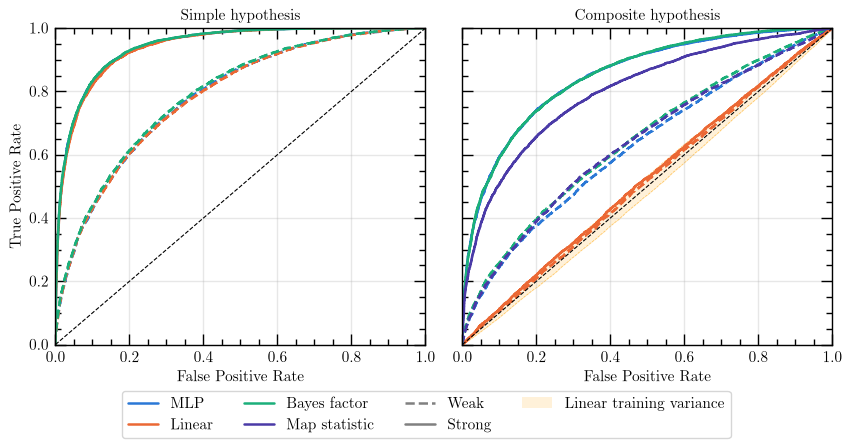

In [4]:
_STRENGTHS_COMBINED = ["weak", "strong"]
_STRENGTH_STYLE = {
    "weak": dict(ls="--", marker="o"),
    "strong": dict(ls="-", marker="^"),
}

_MSTYLE = {
    "mlp":           dict(color=colors[0], lw=1.8),
    "mlp_linear":    dict(color=colors[1], lw=1.8),
    "bayes_factor":  dict(color=colors[2], lw=1.8),
    "map_statistic": dict(color=colors[3], lw=1.8),
}
_MLABEL = {
    "mlp": "MLP", "mlp_linear": " Linear",
    "bayes_factor": "Bayes factor", "map_statistic": "Map statistic",
}
font_size = 11
_BAND_COLOR = "orange"

# Chance band for the linear network (src/chance_band.py): under the
# composite disk prior E[D|H1] = E[D|H0], so its population optimum is w = 0
# and where its test ROC lands is set by the particular training run
# (finite training sample; the fit itself is converged L-BFGS). Pointwise
# mean +- 2 std of the ROC over independently refitted replicas; drawn only
# where the file exists.
bands = {}
for k in _COMPOSITE_KEYS:
    f = Path(f"./plots/{k}/chance_band.npz")
    if f.exists():
        bands[k] = np.load(f)

def plot_roc_figure(out_path):
    fig, axs = plt.subplots(
        ncols=2,
        figsize=pf.set_size(610, subplots=(1, 2), ratio=1),
        sharey=True,
    )
    
    scenario_groups = [
        ("Simple hypothesis", [f"simple_{s}" for s in _STRENGTHS_COMBINED]),
        ("Composite hypothesis", [
            _COMPOSITE_KEYS[_STRENGTHS.index(s)] for s in _STRENGTHS_COMBINED
        ]),
    ]
    roc_handles = []
    roc_labels = []

    for col, (title, keys) in enumerate(scenario_groups):
        ax = axs[col]
        ax.set_title(title, fontsize=font_size)
        for key, strength in zip(keys, _STRENGTHS_COMBINED):
            for method, by_label in rocs[key].items():
                method_style = _MSTYLE.get(method, dict(lw=1.5, color="orange", alpha=0.5))
                roc_style = dict(method_style, ls=_STRENGTH_STYLE[strength]["ls"])
                for _, (fpr, tpr, _) in by_label.items():
                    ax.plot(fpr, tpr, **roc_style)

        for key, strength in zip(keys, _STRENGTHS_COMBINED):
            if key not in bands:
                continue
            b = bands[key]
            lo, hi = b["mean"] - 2 * b["std"], b["mean"] + 2 * b["std"]
            ax.fill_between(b["fpr"], lo, hi,
                            color=_BAND_COLOR, alpha=0.15,
                            lw=0, zorder=0)
            for edge in (lo, hi):
                ax.plot(b["fpr"], edge, color=_BAND_COLOR,
                        lw=0.5, alpha=0.6, ls=_STRENGTH_STYLE[strength]["ls"],
                        zorder=0)

        ax.plot([0, 1], [0, 1], "k--", lw=0.8)
        #ax.axvline(0.05, color="orange", alpha=0.5, ls=":", lw=0.8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("False Positive Rate", fontsize=font_size)
        if col == 0:
            ax.set_ylabel("True Positive Rate", fontsize=font_size)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="both", labelsize=font_size)
        pf.set_custom_tick_options(ax, width=1, lenght=4)

    present_methods = {method for _, keys in scenario_groups
                       for key in keys for method in rocs[key]}
    for method in _MSTYLE:
        if method in present_methods:
            roc_handles.append(plt.Line2D([0], [0], **_MSTYLE[method]))
            roc_labels.append(_MLABEL[method])


    # axs[1].legend(
    #     roc_handles,
    #     roc_labels,
    #     loc="lower right", 
    #     ncol=1, 
    #     fontsize=font_size,
    #     frameon=True,
    # )

    to_append_handles = {
        "Weak": dict(color='grey', lw=1.8, linestyle="--"),
        "Strong": dict(color='grey', lw=1.8),
    }

    for label, style in to_append_handles.items():
        roc_handles.append(plt.Line2D([0], [0], **style))
        roc_labels.append(label)

    if bands:
        roc_handles.append(matplotlib.patches.Patch(
            color=_BAND_COLOR, alpha=0.15, lw=0))
        roc_labels.append(r"Linear training variance") # \\variance $2\sigma$")
        
    pf.square_panels(fig, wspace=0.1)

    fig.subplots_adjust(bottom=0.225)
    fig.legend(roc_handles, roc_labels, loc="lower center", ncol=4, fontsize=font_size, frameon=True)
    fig.savefig(out_path)
    plt.show()


plot_roc_figure("figures/plot_roc.pdf")

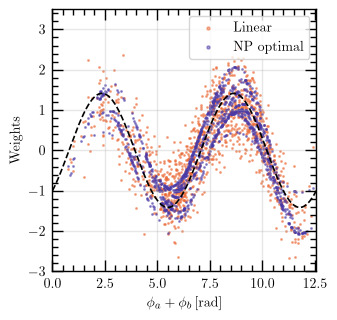

In [5]:
font_size = 10

def plot_weights_figure(out_path, key="simple_weak"):
    fig, ax = plt.subplots(
        figsize=pf.set_size(246, ratio=1))

    x_theory = np.linspace(0.0, 4.0 * np.pi, 500)
    theory = np.cos(x_theory + np.pi / 4.0)
    theory = -_rms(theory)

    data = w_data[key]
    order = np.argsort(data["phi_ab"])

    ax.scatter(
        data["phi_ab"][order], data["w_mlp"][order],
        color=colors[1], s=1.2, alpha=0.5, label="Linear",
    )
    ax.scatter(
        data["phi_ab"][order], data["w_np"][order],
        color=colors[3], s=1.2, alpha=0.5, label="NP optimal",
    )
    ax.plot(
        x_theory, theory, color="black", lw=1.2, ls="--",
    )
    ax.set_xlim(0.0, 4.0 * np.pi)
    ax.set_ylim(-3, 3.5)
    ax.set_xlabel(r"$\phi_a + \phi_b\,{\rm [rad]}$", fontsize=font_size)
    ax.set_ylabel("Weights", fontsize=font_size)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=font_size)
    pf.set_custom_tick_options(ax, width=1, lenght=4)


    ax.legend(
        loc="upper right", ncol=1, markerscale=2, fontsize=font_size, frameon=True)

    fig.savefig(out_path)
    plt.show()

plot_weights_figure("figures/weights.pdf")

## Bayes factor comparison

In [6]:
SCENARIOS = ["simple_strong", "composite_strong"]
N_POINTS = 1000  # total points PER SCENARIO, split evenly between null and signal

logBF, out_mlp, out_mlp_linear, is_signal = {}, {}, {}, {}

for scen in SCENARIOS:
    cfg = load_config(f"./config_files/{scen}.py")
    ds = np.load(f"./out/{scen}/datasets.npz")
    label = cfg.test_scenarios[0]["label"]
    phi_j, Ns = jnp.array(ds["_phi_j"]), int(ds["_Ns"])
    mu, sig_std = ds["_mu"], ds["_sig_std"]

    # Fresh generator per scenario, so each draw is reproducible on its own
    # and does not depend on its position in SCENARIOS.
    rng = np.random.default_rng(0)
    n_half = N_POINTS // 2

    D_null, D_sig = ds["D_test_null"], ds[f"D_test_sig_{label}"]
    idx_null = rng.choice(len(D_null), size=n_half, replace=False)
    idx_sig = rng.choice(len(D_sig), size=N_POINTS - n_half, replace=False)

    D_sample = np.concatenate([D_null[idx_null], D_sig[idx_sig]], axis=0)
    is_signal[scen] = np.concatenate([
        np.zeros(n_half, dtype=bool),
        np.ones(N_POINTS - n_half, dtype=bool),
    ])

    logBF[scen] = exact_log_bf(
        D_sample, phi_j, Ns, cfg.bf_priors, cfg.bf_log_uniform, cfg.n_mc_bf,
    )
    out_mlp[scen] = net_output(
        load_model(f"./out/{scen}/mlp.pkl"), D_sample, mu, sig_std
    )
    out_mlp_linear[scen] = net_output(
        load_model(f"./out/{scen}/mlp_linear.pkl"), D_sample, mu, sig_std
    )

    print(f"{scen}: {n_half} null + {N_POINTS - n_half} signal "
        f"(label={label}, n_pul={len(ds['_phi_j'])})")

100%|██████████| 1000/1000 [00:06<00:00, 165.74it/s]


simple_strong: 500 null + 500 signal (label=strong, n_pul=50)


100%|██████████| 1000/1000 [00:05<00:00, 178.88it/s]

composite_strong: 500 null + 500 signal (label=strong, n_pul=50)


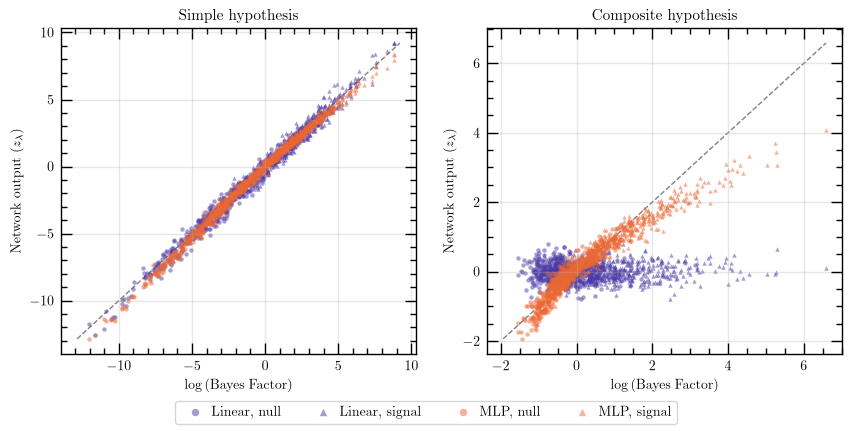

saved: figures/bf_vs_net.pdf


In [7]:
font_size = 10

_TITLE = {
    "simple_strong": "Simple hypothesis",
    "composite_strong": "Composite hypothesis",
}
# colour = network, marker = null/signal
_NETS = [("Linear", out_mlp_linear, colors[3]),
        ("MLP",        out_mlp,        colors[1])]
_KINDS = [(False, "o", "null"), (True, "^", "signal")]

add_labels = True
def _corr(x, y):
    return np.corrcoef(x, y)[0, 1]


fig, axs = plt.subplots(
    1, 2,
    figsize=pf.set_size(610, subplots=(1, 2), ratio=1),
)

for ax, scen in zip(axs, SCENARIOS):
    lb, sig = np.asarray(logBF[scen]), is_signal[scen]
    rs = []

    for name, out_dict, color in _NETS:
        out = np.asarray(out_dict[scen])
        rs.append(f"{name} $r={_corr(lb, out):.3f}$")
        for flag, marker, kind in _KINDS:
            m = sig == flag
            if add_labels:
                ax.scatter(lb[m], out[m], s=10, alpha=0.5, color=color,
                            marker=marker, linewidths=0, label=f"{name}, {kind}")
                
            else:
                ax.scatter(lb[m], out[m], s=10, alpha=0.5, color=color,
                            marker=marker, linewidths=0)

    # limits from the data: the two scenarios span very different ranges
    vals = np.concatenate([lb] + [np.asarray(d[scen]) for _, d, _ in _NETS])
    lo, hi = vals.min(), vals.max()
    pad = 0.05 * (hi - lo)
    ax.plot([lo, hi], [lo, hi], color="k", alpha=0.5, lw=1, ls="--", zorder=0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)

    ax.set_title(_TITLE.get(scen, scen), fontsize=font_size + 1)
    ax.set_xlabel(r"$\log\,(\mathrm{Bayes\;Factor})$", fontsize=font_size)
    ax.set_ylabel(r"Network output ($z_\lambda$)", fontsize=font_size)

    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=font_size)
    pf.set_custom_tick_options(ax, width=1, lenght=4)
    
    add_labels = False  # only label the first panel, not the second

# axs[0].legend(fontsize=font_size, frameon=False, loc="lower right",
#             ncol=1, markerscale=1.7, handletextpad=0.2)

pf.square_panels(fig, wspace=0.2)

fig.subplots_adjust(bottom=0.175)
fig.legend(loc="lower center", ncol=4, fontsize=font_size, frameon=True, markerscale=1.7, handletextpad=0.2)
out_path = "figures/bf_vs_net.pdf"
fig.savefig(out_path)
plt.show()
print(f"saved: {out_path}")